In [4]:
498.75*1/3

166.25

In [3]:
1581.75*1/3

527.25

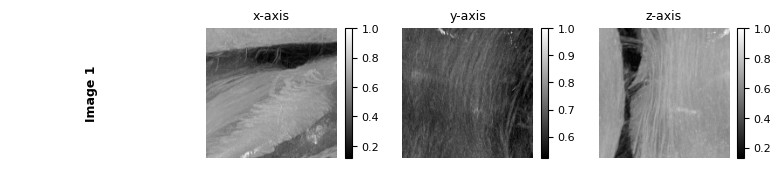

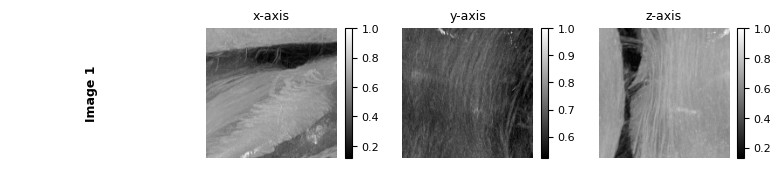

In [9]:
from core.loader import Loader
from core.saver import Saver
from view.viewer import Viewer

data = Loader('data/draft/').load_data('mouse_brain.nii', crop=True, target_shape=(150, 150, 150))
Viewer().display_mip(data)

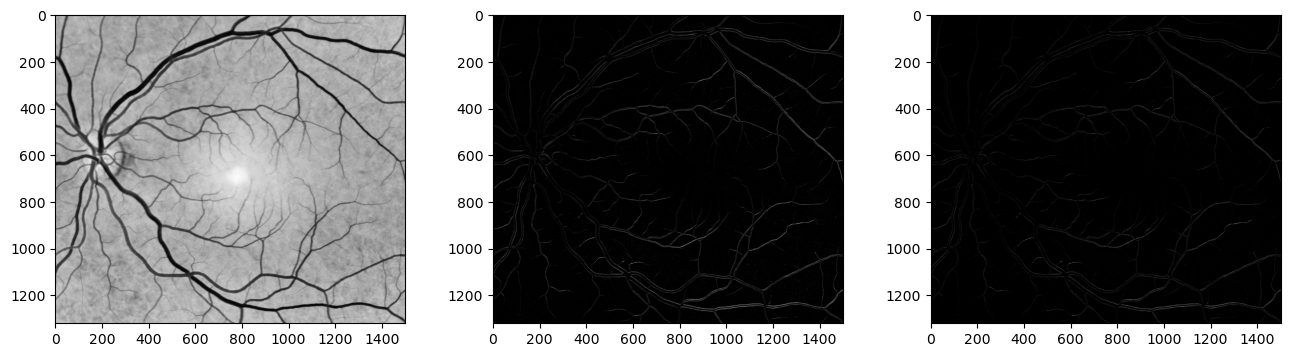

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from core.loader import Loader
from skimage.filters import frangi 

image_raw = Loader('data/test').load_data('test.jpg')
image_enhanced_1 = frangi(
    image=image_raw,
    sigmas=np.arange(1, 10, 1), 
    alpha=0.5,
    beta=0.5,
    gamma=None,  
    black_ridges=False,
)
image_enhanced_2 = frangi(
    image=image_raw,
    sigmas=np.arange(1, 10, 1), 
    alpha=0.5,
    beta=0.5,
    gamma=15,  
    black_ridges=False,
)

fig = plt.figure(figsize=(16, 4))
plt.subplot(1, 3, 1)
plt.imshow(-image_raw, cmap='gray')
plt.subplot(1, 3, 2)
plt.imshow(image_enhanced_1, cmap='gray')
plt.subplot(1, 3, 3)
plt.imshow(image_enhanced_2, cmap='gray')



In [ ]:
from core.loader import Loader
from src.pipeline import Pipeline
from core.config import SetupConfig
from src.enhancer import Enhancer

SetupConfig(
        name="test_benchmark",
        log_file="test",
        input_dir="data/test",
        output_dir=str("out"),
        debug_mode=True,
        display_mode=True,
        save_mode=False,
    )

raw = Loader('data/test').load_data('test_raw.nii', crop=False)
enhanced = Enhancer().frangi(
    image=raw, 
    hessian_params={'mode': 'reflect','cval': 0,'use_gaussian_derivatives': True},
    skimage=True,
    scales=range(1, 10, 2)
)


12:34:32 - [INFO]: [LOAD] Data test_raw.nii loaded with shape (195, 155, 150) and normalized.
12:34:32 - [INFO]: The enhancement is done with frangi function from skimage.


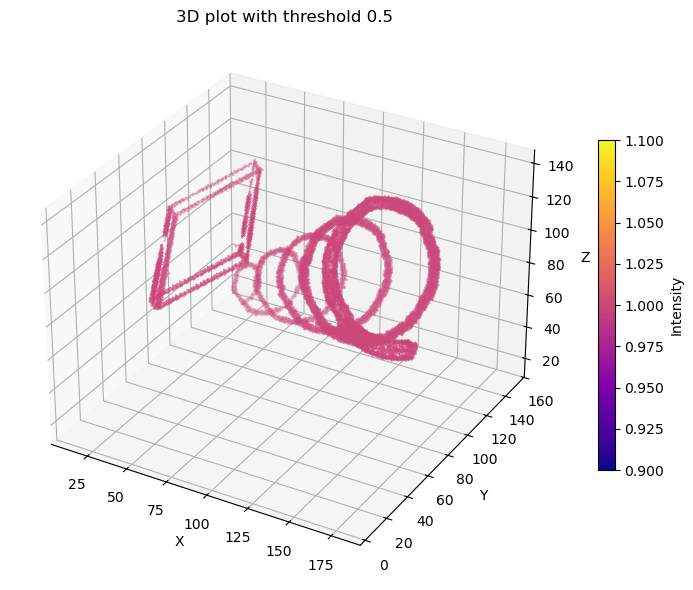

12:40:29 - [INFO]: [SAVE] Data file test_gt.nii saved at data\test\2025-07-11_12-40-29_test_gt\data_test_gt.


In [ ]:
from view.viewer import Viewer
from core.saver import Saver
import numpy as np
segmented = (enhanced > 0.02).astype(np.uint8)
Viewer().display_volume(segmented, 0.5)
Saver("test_gt", "data/test").save_data(segmented, "test_gt", '.nii')

12:42:42 - [INFO]: [LOAD] Data test_gt.nii loaded with shape (195, 155, 150) and normalized.


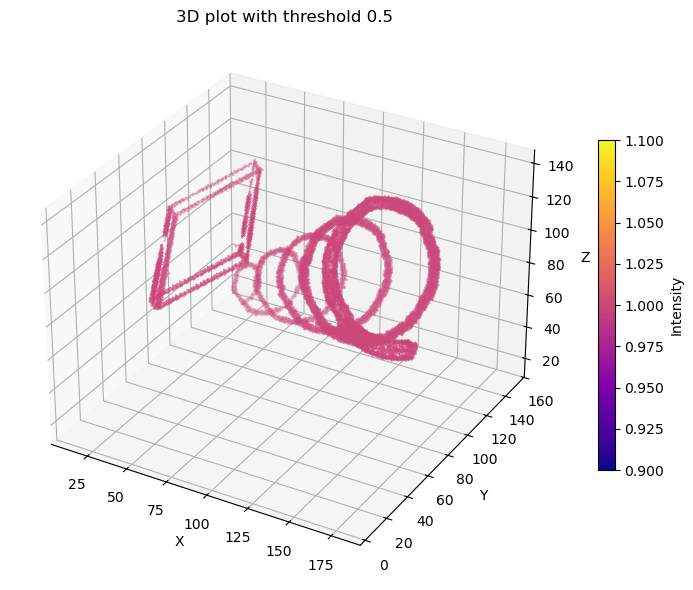

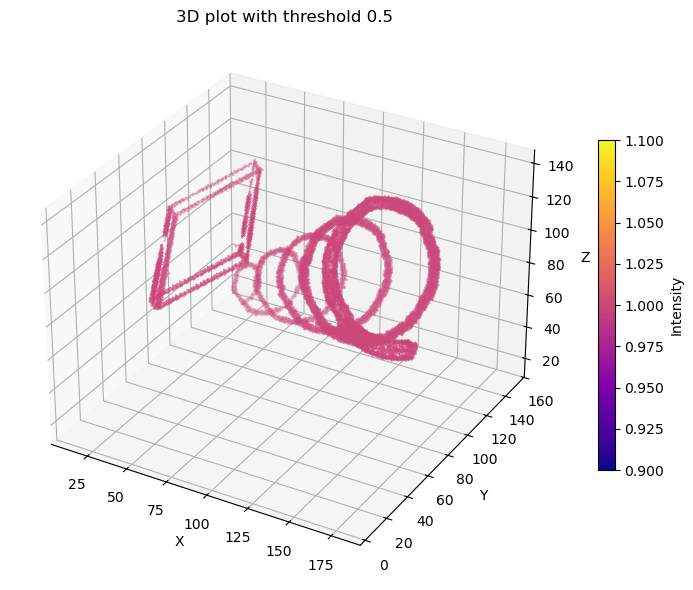

In [42]:
data = Loader('data/test').load_data('test_gt.nii', crop=False)
Viewer().display_volume(data, 0.5)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from benchmark.computational_time import scale_size_influence, volume_size_influence, chunk_number_influence

scale_size_influence(32, (1, 10), [2, 4], 'frangi', 2)
volume_size_influence(np.array([32, 64]), 2, (1, 10), 'frangi', 2)
chunk_number_influence([32, 64], 2, (1, 10), 'frangi', [2, 4])

[########################################] | 100% Completed | 2.18 sms
[########################################] | 100% Completed | 4.10 sms
08:35:38 - [INFO]: ======================================== RESUME ========================================

08:35:38 - [INFO]: 
Influence du nombre d'échelle sur le temps d'exécution du réhaussement

08:35:38 - [INFO]: Scales number:    [2, 4]
08:35:38 - [INFO]: Times sequential: [0.4265462999974261, 0.526276800002961]
08:35:38 - [INFO]: Times parallel:   [6.470020900000236, 4.167211899999529]
08:35:38 - [INFO]: 
|   Scales (num) |   Time sequential (s) |   Time parallel (s) |
|----------------|-----------------------|---------------------|
|              2 |                 0.427 |               6.470 |
|              4 |                 0.526 |               4.167 |
08:35:38 - [INFO]: ========================================================================================

[########################################] | 100% Completed | 2.52 sms


([32, 64],
 [2, 4],
 [[16, 8], [32, 16]],
 [[2.6615614000038477, 2.6376338000045507],
  [3.5068361000012374, 23.19713519999641]])